In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "20"
os.environ["MKL_NUM_THREADS"] = "20"

import torch
torch.set_num_threads(20)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
import random
import numpy as np
from pathlib import Path
from tqdm import tqdm
from PIL import Image

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
class Stage1Dataset(Dataset):

    def __init__(self, root, transform=None):

        self.root = Path(root)
        self.transform = transform
        self.samples = []

        normal_folder = self.root / "Normal"
        abnormal_folder = self.root / "Abnormal"

        exts = (".jpg",".jpeg",".png")

        for p in normal_folder.rglob("*"):
            if p.suffix.lower() in exts:
                self.samples.append((str(p),0))

        for p in abnormal_folder.rglob("*"):
            if p.suffix.lower() in exts:
                self.samples.append((str(p),1))


    def __len__(self):
        return len(self.samples)


    def __getitem__(self, idx):

        path, label = self.samples[idx]

        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label)

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [6]:
DATA_ROOT = r"C:\Users\amarh\Desktop\My Professionals\Projects\CCTV Crime\Datasets\Test"

dataset = Stage1Dataset(DATA_ROOT, transform)

print("Total images:", len(dataset))

Total images: 111308


In [7]:
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
)

In [8]:
MODEL_PATH = r"C:\Users\amarh\Desktop\My Professionals\Projects\CCTV Crime\Models\stage1_epoch_3.pth"

mobilenet = models.mobilenet_v2(pretrained=False)

mobilenet.classifier = nn.Identity()

class Stage1Model(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = mobilenet
        self.head = nn.Linear(1280,2)

    def forward(self,x):

        x = self.backbone(x)
        return self.head(x)


model = Stage1Model()

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

model = model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


C:\Users\amarh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\amarh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [32]:
all_preds = []
all_labels = []

correct = 0
total = 0

threshold = 0.03

with torch.no_grad():

    for imgs, labels in tqdm(loader):

        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs)

        probs = torch.softmax(logits, dim=1)

        crime_probs = probs[:,1]

        preds = (crime_probs > threshold).int()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

100%|██████████| 3479/3479 [30:25<00:00,  1.91it/s]


In [33]:
accuracy = correct / total

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.7702231645524131


In [34]:
print("\nClassification Report\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Normal","Crime"]
    )
)

print("\nConfusion Matrix\n")

print(confusion_matrix(all_labels, all_preds))


Classification Report

              precision    recall  f1-score   support

      Normal       0.88      0.71      0.78     64952
       Crime       0.68      0.86      0.76     46356

    accuracy                           0.77    111308
   macro avg       0.78      0.78      0.77    111308
weighted avg       0.79      0.77      0.77    111308


Confusion Matrix

[[45921 19031]
 [ 6545 39811]]


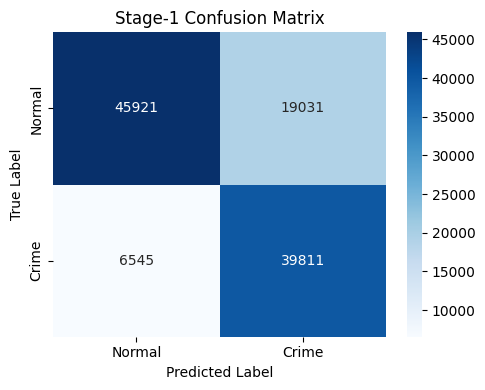

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([[45921 ,19031],
               [ 6545 ,39811]])

labels = ["Normal", "Crime"]

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Stage-1 Confusion Matrix")

plt.tight_layout()
plt.savefig("stage1_confusion_matrix.png", dpi=300)
plt.show()